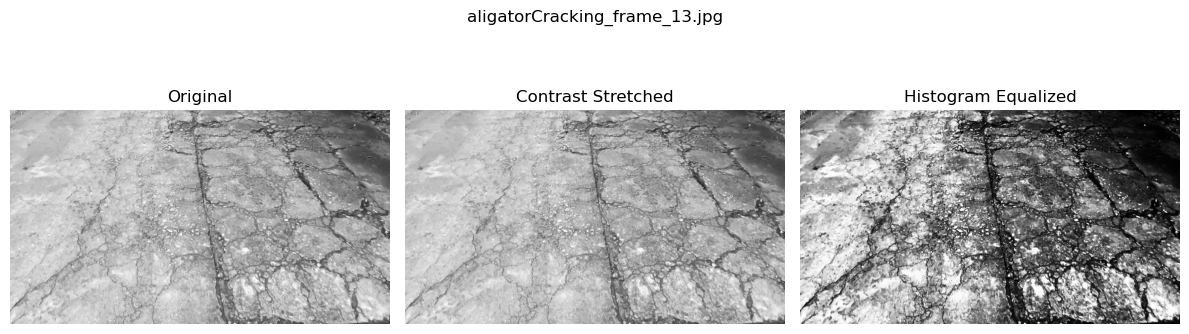

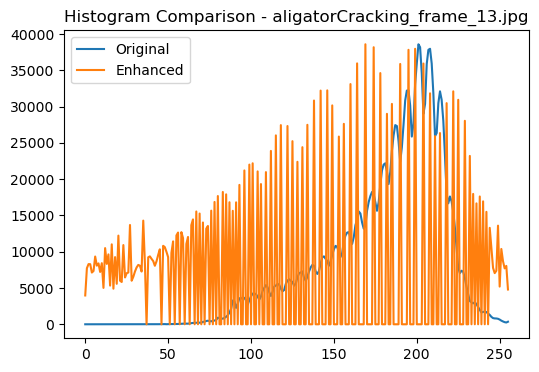

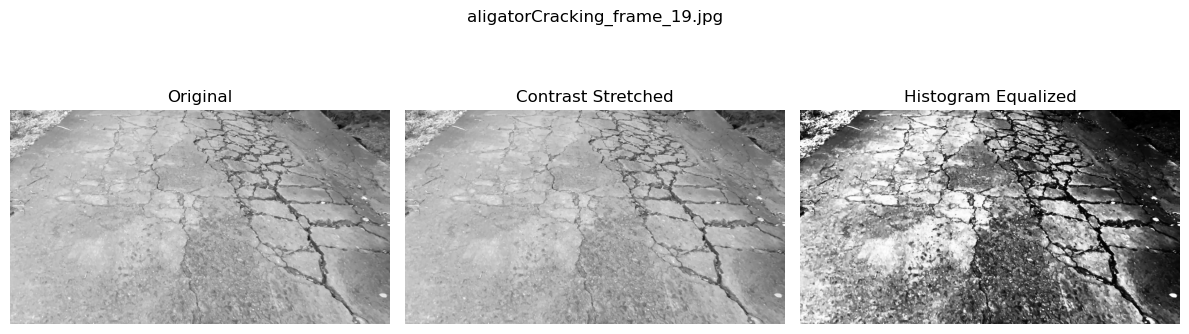

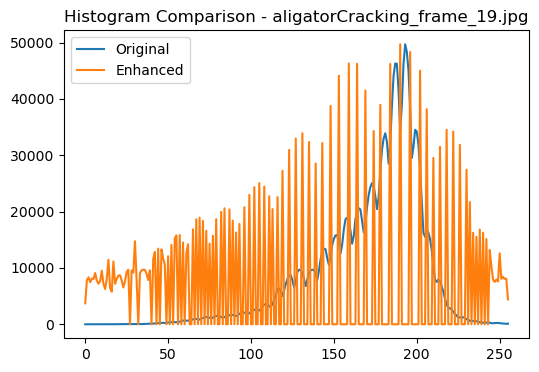

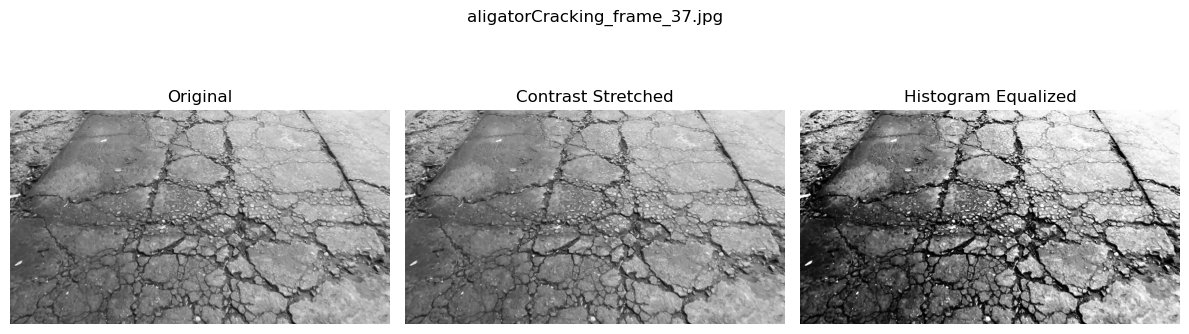

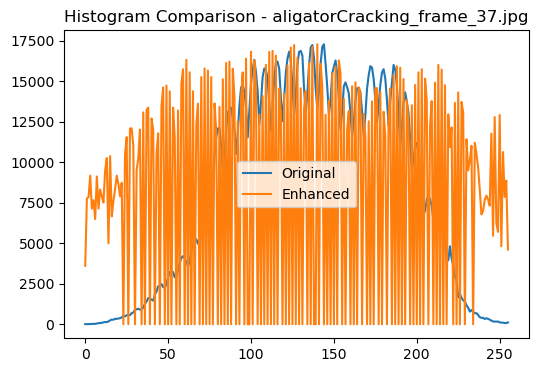

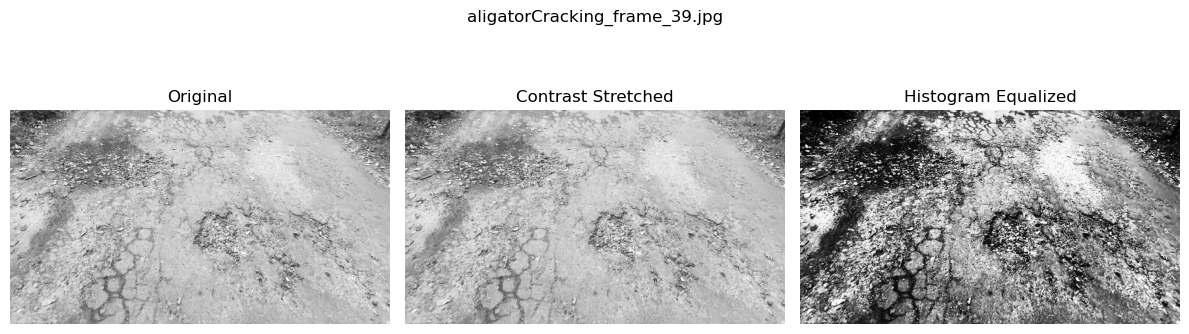

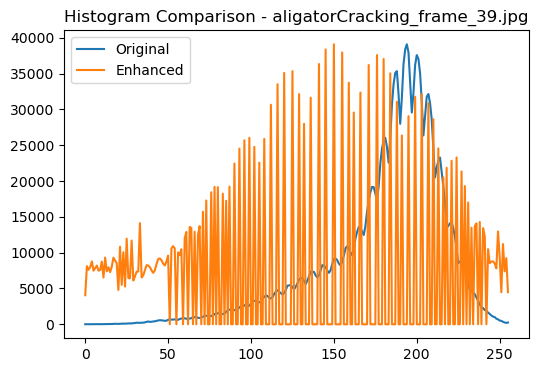

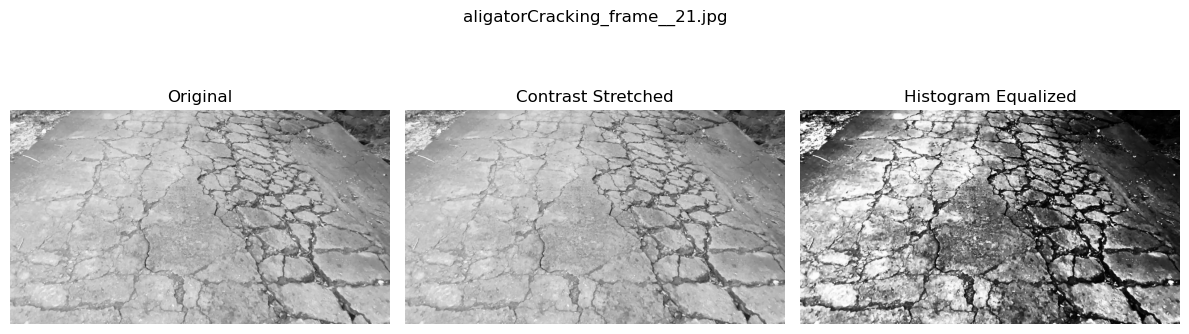

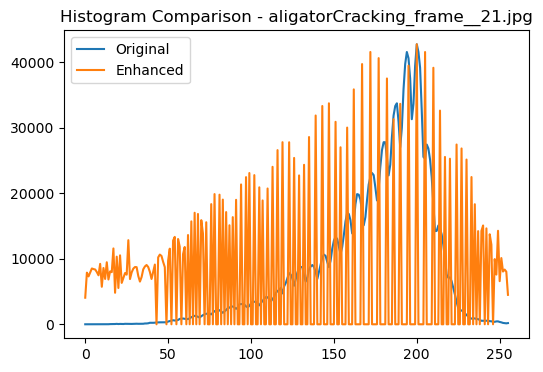


Illumination Enhancement Completed.

========== ENHANCEMENT EVALUATION ==========
                              Frame  Contrast Before (Std Dev)  \
0     aligatorCracking_frame_13.jpg                  33.826335   
1     aligatorCracking_frame_19.jpg                  30.619536   
2     aligatorCracking_frame_37.jpg                  44.511295   
3     aligatorCracking_frame_39.jpg                  35.617408   
4    aligatorCracking_frame__21.jpg                  34.146722   
5    aligatorCracking_frame__24.jpg                  36.086385   
6    aligatorCracking_frame__29.jpg                  34.249658   
7             raveling_frame_21.jpg                  38.343402   
8             raveling_frame_26.jpg                  36.582698   
9             raveling_frame_28.jpg                  34.111718   
10            raveling_frame_30.jpg                  38.608772   
11            raveling_frame_31.jpg                  44.447311   
12            raveling_frame_35.jpg                  40.650

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

input_folder = "frames"

# Contrast Stretching Function
def contrast_stretch(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val == 0:
        return image.copy()

    stretched = (image.astype(np.float32) - min_val) * (255.0 / (max_val - min_val))
    return stretched.astype(np.uint8)

# Entropy Calculation
def calculate_entropy(image):
    hist = cv2.calcHist([image],[0],None,[256],[0,256])
    hist = hist / hist.sum()
    hist = hist.flatten()
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    return entropy

results = []

frame_files = sorted(os.listdir(input_folder))

display_count = 0
max_display = 5

for file in frame_files:

    if file.lower().endswith((".jpg", ".png", ".jpeg", ".bmp", ".tif", ".tiff")):

        path = os.path.join(input_folder, file)
        img = cv2.imread(path, 0)

        if img is None:
            continue

        # Contrast Stretching
        stretched = contrast_stretch(img)

        # Histogram Equalization
        hist_eq = cv2.equalizeHist(stretched)

        # Evaluation Metrics
        std_before = np.std(img)
        std_after = np.std(hist_eq)

        entropy_before = calculate_entropy(img)
        entropy_after = calculate_entropy(hist_eq)

        results.append([
            file,
            std_before,
            std_after,
            entropy_before,
            entropy_after
        ])

        # Display Frames
        if display_count < max_display:

            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.imshow(img, cmap="gray")
            plt.title("Original")
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.imshow(stretched, cmap="gray")
            plt.title("Contrast Stretched")
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.imshow(hist_eq, cmap="gray")
            plt.title("Histogram Equalized")
            plt.axis("off")

            plt.suptitle(file)
            plt.tight_layout()
            plt.show()

            # Histogram comparison
            plt.figure(figsize=(6,4))

            hist_orig = cv2.calcHist([img],[0],None,[256],[0,256])
            hist_enhanced = cv2.calcHist([hist_eq],[0],None,[256],[0,256])

            plt.plot(hist_orig, label="Original")
            plt.plot(hist_enhanced, label="Enhanced")
            plt.title(f"Histogram Comparison - {file}")
            plt.legend()
            plt.show()

            display_count += 1

print("\nIllumination Enhancement Completed.")

#Evaluation Table
df = pd.DataFrame(
    results,
    columns=[
        "Frame",
        "Contrast Before (Std Dev)",
        "Contrast After (Std Dev)",
        "Entropy Before",
        "Entropy After"
    ]
)

print("\n========== ENHANCEMENT EVALUATION ==========")
print(df)

if not df.empty:

    avg_std_before = df["Contrast Before (Std Dev)"].mean()
    avg_std_after = df["Contrast After (Std Dev)"].mean()

    avg_entropy_before = df["Entropy Before"].mean()
    avg_entropy_after = df["Entropy After"].mean()

    print("\nAverage Contrast Before :", round(avg_std_before, 2))
    print("Average Contrast After  :", round(avg_std_after, 2))
    print("Average Contrast Gain   :", round(avg_std_after - avg_std_before, 2))

    print("\nAverage Entropy Before  :", round(avg_entropy_before, 2))
    print("Average Entropy After   :", round(avg_entropy_after, 2))
    print("Average Entropy Gain    :", round(avg_entropy_after - avg_entropy_before, 2))

    if avg_std_after > avg_std_before:
        print("\nInterpretation: Contrast improved according to standard deviation.")
    else:
        print("\nInterpretation: No significant contrast improvement detected.")

    if avg_entropy_after > avg_entropy_before:
        print("Interpretation: Information content increased after enhancement.")